In [66]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
mnist


{'data': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784)),
 'target': array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object),
 'frame': None,
 'categories': {'class': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']},
 'feature_names': ['pixel1',
  'pixel2',
  'pixel3',
  'pixel4',
  'pixel5',
  'pixel6',
  'pixel7',
  'pixel8',
  'pixel9',
  'pixel10',
  'pixel11',
  'pixel12',
  'pixel13',
  'pixel14',
  'pixel15',
  'pixel16',
  'pixel17',
  'pixel18',
  'pixel19',
  'pixel20',
  'pixel21',
  'pixel22',
  'pixel23',
  'pixel24',
  'pixel25',
  'pixel26',
  'pixel27',
  'pixel28',
  'pixel29',
  'pixel30',
  'pixel31',
  'pixel32',
  'pixel33',
  'pixel34',
  'pixel35',
  'pixel36',
  'pixel37',
  'pixel38',
  'pixel39',
  'pixel40',
  'pixel41',
  'pixel42',
  'pixel43',
  'pixel44',


In [67]:
X,y=mnist["data"],mnist["target"]
X.shape
y.shape

(70000,)

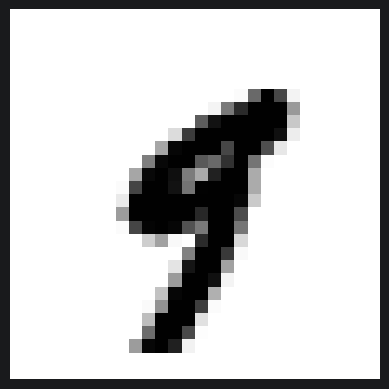

'9'

In [68]:
import matplotlib_inline
import matplotlib.pyplot as plt
import numpy as np
some_digit=X[36000]
some_digit_image=some_digit.reshape(28,28)
plt.imshow(some_digit_image,cmap="binary",interpolation="nearest")
plt.axis('off')
plt.show()
y[36000]


In [69]:
X_train,X_test,y_train,y_test=X[:60000],X[60000:],y[:60000],y[60000:]
# shuffling the indexes to make sure algorithm performs well
shuffle_index=np.random.permutation(60000)
X_train,y_train=X_train[shuffle_index],y_train[shuffle_index]


In [70]:
# creating classification
y_train_5= (y_train == '5')
y_test_5=(y_test == '5')
some_digit=X[15000]
y[15000]

'5'

In [71]:
from sklearn.linear_model import SGDClassifier
sgd_clf=SGDClassifier(random_state=42)
sgd_clf.fit(X_train,y_train_5)
sgd_clf.predict([some_digit])

array([ True])

In [72]:
# customizing cross validation
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
skfolds=StratifiedKFold(n_splits=3,shuffle=True,random_state=42)
for train_index,test_index in skfolds.split(X_train,y_train_5):
    clone_clf=clone(sgd_clf)
    X_train_folds=X_train[train_index]
    y_train_folds=(y_train_5[train_index])
    X_test_fold=X_train[test_index]
    y_test_fold=(y_train_5[test_index])

    clone_clf.fit(X_train_folds,y_train_folds)
    y_pred=clone_clf.predict(X_test_fold)
    n_correct=sum(y_pred==y_test_fold)
    print(n_correct/len(y_pred))

0.9606
0.9651
0.9672


In [73]:
# cross validation using direct method
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf,X_train,y_train_5,cv=3,scoring='accuracy')


array([0.9652 , 0.96875, 0.9569 ])

In [74]:
# crossing checking with basic classifier
from sklearn.base import BaseEstimator
class Never5Classifier(BaseEstimator):
    def fit(self,X,y=None):
        pass
    def predict(self,X):
        return np.zeros((len(X),1),dtype=bool)

In [75]:
#testing
never_5_clf=Never5Classifier()
cross_val_score(never_5_clf,X_train,y_train_5,cv=3,scoring='accuracy')


array([0.91035, 0.9098 , 0.9088 ])

In [76]:
# using cross_val_predict for precise prediction
from sklearn.model_selection import cross_val_predict
y_train_pred=cross_val_predict(sgd_clf,X_train,y_train_5,cv=3)
y_train_pred

array([False, False, False, ...,  True, False, False], shape=(60000,))

In [77]:
# using confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5,y_train_pred)
# row -- actually what it was and column -- what predicted
#     0 1
#  0
#  1
 #  ex: if zero and predicted 0 then added at (1,1)


array([[53538,  1041],
       [ 1142,  4279]])

In [78]:
# precision
from sklearn.metrics import precision_score,recall_score
precision_score(y_train_5,y_train_pred)


0.8043233082706767

In [79]:
#recall
recall_score(y_train_5,y_train_pred)

0.7893377605607822

In [80]:
# harmonic mean of precision and recall is f1
from sklearn.metrics import f1_score
f1_score(y_train_5,y_train_pred)

0.7967600782050088

In [81]:
# using decision function to understand threshold
y_scores=sgd_clf.decision_function([some_digit])
y_scores

array([285.84108756])

In [82]:
threshold=0
y_some_digit_pred=(y_scores>threshold)
y_some_digit_pred


array([ True])

In [83]:
# changing threshold
threshold=20000
y_some_digit_pred=(y_scores>threshold)
y_some_digit_pred
# here after increasing the threshold precision increases recall decreases


array([False])

In [84]:
y_scores=cross_val_predict(sgd_clf,X_train,y_train_5,cv=3,method="decision_function")
y_scores


array([-21634.66310225,   -298.64222656, -16494.60462354, ...,
         4596.46205545,  -8503.40078929, -14392.82112777], shape=(60000,))

In [85]:
# plotting the recall and precision function
from sklearn.metrics import precision_recall_curve
precisions,recalls,threshold=precision_recall_curve(y_train_5,y_scores)


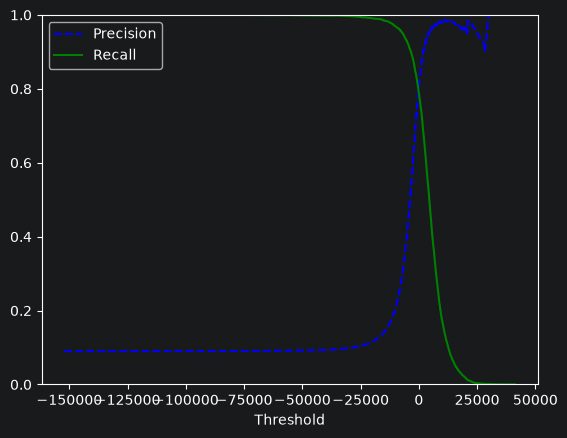

In [86]:
# creating fun to plot
import seaborn as sns
def plot_precision_recall_vs_threshold(precision,recall,threshold):
    plt.plot(threshold,precision[:-1],"b--",label="Precision")
    plt.plot(threshold,recall[:-1],"g-",label="Recall")
    plt.xlabel("Threshold")
    plt.legend()
    plt.ylim([0,1])
    plt.show()




plot_precision_recall_vs_threshold(precisions,recalls,threshold)


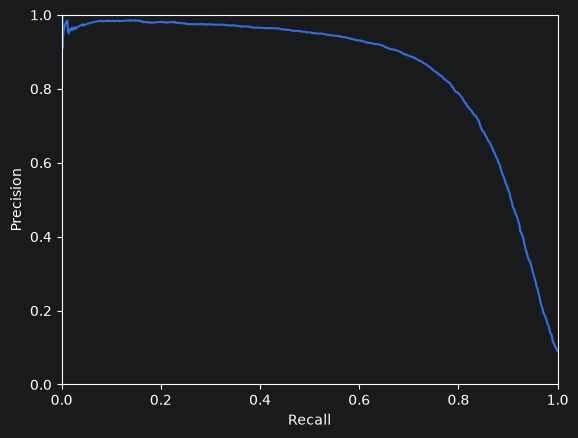

In [87]:
# plotting recall and precision
sns.lineplot(x=recalls,y=precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.ylim([0,1])
plt.xlim([0,1])
plt.show()

In [88]:
# precision classifier
y_train_pred_90=(y_scores>25000)
y_train_pred_90

array([False, False, False, ..., False, False, False], shape=(60000,))

In [89]:
# precision score
precision_score(y_train_5,y_train_pred_90)

0.95

In [90]:
# recall score
recall_score(y_train_5,y_train_pred_90)


0.003504888396974728

In [91]:
# here we understand that precision at 90 alone is not good enough when the recall is very less ,i.e the classifier is failing to predict what where the real 5s but not predictedsaw

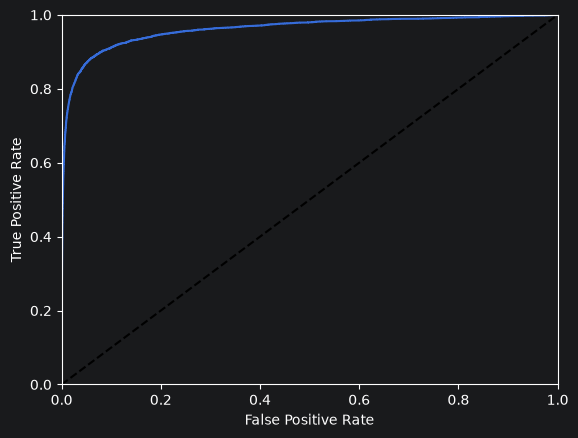

In [92]:
from sklearn.metrics import roc_curve
fpr,tpr,threshold=roc_curve(y_train_5,y_scores)
def plot_roc_curve(fpr,tpr,threshold):
    plt.plot(fpr,tpr,label=None)
    plt.plot([0,1],[0,1],'k--')
    plt.axis([0,1,0,1])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
plot_roc_curve(fpr,tpr,threshold)
plt.show()

In [93]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5,y_scores)

0.9616944356813869

In [ ]:
# trying random forest classifier
from sklearn.ensemble import RandomForestClassifier
forest_clf=RandomForestClassifier(random_state=42)
y_probas_forest=cross_val_predict(forest_clf,X_train,y_train_5,cv=5,method="predict_proba")
y_probas_forest

In [ ]:
y_scores_forest=y_probas_forest[:,1] # score = proba of positive class


fpr_forest,tpr_forest,threshold=roc_curve(y_train_5,y_scores_forest)
plt.plot(fpr,tpr,"b:",label="SGD")
plot_roc_curve(fpr_forest,tpr_forest,"Random Forest")
plt.legend(loc="lower right")
plt.show()

In [ ]:
# auc score for random forest
roc_auc_score(y_train_5,y_scores_forest)
